# 03_集成算法-堆叠

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 堆叠调参改为对完整 StackingRegressor 交叉验证，避免用基模型对其训练数据的拟合值调优元模型。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家聊聊堆叠（Stacking）\~

堆叠是一种**集成学习（Ensemble Learning）**的方法，简单来说就是“团队合作，让多个模型一起决策”。

当你要预测明天的天气，但你不想只听一个天气预报员的意见。于是，你找来了几个天气预报员，他们分别用不同的方法来预测天气，比如：

- 预报员A：根据过去一周的天气来判断
- 预报员B：用气象模型分析温度、湿度等因素
- 预报员C：参考卫星云图来预测降雨概率

但他们的预测可能不一样，所以你请来一位“总裁判”（也叫**元学习器，Meta Learner**），这个总裁判会根据每个预报员的历史表现，综合他们的预测，得出最终的天气结论。

#### 堆叠的基本流程

1. **第一层（基础模型，Base Models）**：用多个不同的模型（比如决策树、随机森林、神经网络等）对同一份数据进行学习，分别输出预测结果。
2. **第二层（元学习器，Meta Learner）**：收集第一层模型的预测结果，把这些预测结果当作新数据，再用一个更强的模型（比如线性回归、XGBoost等）来学习如何综合这些预测结果，最终得出最优的预测。

#### 为什么要用堆叠？

- **比单个模型更聪明**：不同模型擅长处理不同类型的数据，结合它们的优点能让预测更准确。
- **减少过拟合**：单个模型可能会犯某种固定的错误，但多个模型一起决策，可以互相弥补缺陷。
- **灵活性高**：可以自由搭配不同类型的模型，比如简单的决策树+复杂的神经网络，让它们互相补充。

## 原理详解

堆叠通过**多个基础模型（Base Models）的预测结果，输入到一个元模型（Meta Learner）**中进行二次学习，以提高预测精度。

数学上，堆叠本质上是一个**层次化的学习结构**，第一层包含多个基础学习器，第二层是一个元学习器，它学习如何组合第一层的输出，以最优方式得到最终预测。

### 问题设定

假设我们有一个监督学习问题：

- 训练集：$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}$，其中 $x_i$是输入特征，$y_i$是目标变量。
- 目标：学习一个映射函数 $f: X \to Y$，使得给定新输入 $x$时，能预测 $y$。

在 Stacking 中，我们不直接学习一个函数 $f(x)$，而是通过多个基础模型 $f_1, f_2, ..., f_M$的组合来学习最终的 $\hat{y}$。

### 两层 Stacking 结构

Stacking 采用分层策略：

**第一层（基础模型层）**：

- 训练多个不同的基础学习器 $f_1, f_2, ..., f_M$。
- 每个模型 $f_m$训练后独立预测目标变量：  
$\hat{y}_m = f_m(x)$

**第二层（元学习器）**：

- 用第一层基础模型的预测结果 $(\hat{y}_1, \hat{y}_2, ..., \hat{y}_M)$作为新的输入，训练一个新的元学习器 $g$，学习最终预测：  
$\hat{y} = g(\hat{y}_1, \hat{y}_2, ..., \hat{y}_M)$

在数学上，最终的预测函数可以表示为：  
$\hat{y} = g(f_1(x), f_2(x), ..., f_M(x))$

其中：

$f_m(x)$是基础学习器的预测结果，

$g(\cdot)$是元学习器，它学习如何组合多个基础学习器的预测。

## 公式推导

#### 第一层：基础模型

对于每个基础模型 $f_m$，其训练过程是最小化损失函数：  
$\min_{\theta_m} \sum_{i=1}^{N} L(y_i, f_m(x_i; \theta_m))$  
其中：

$L(y, \hat{y})$是损失函数（如 MSE、交叉熵损失等），

$\theta_m$是模型参数，

$f_m(x_i; \theta_m)$是第 $m$个基础学习器对样本 $x_i$的预测值。

训练完成后，我们可以得到第一层所有模型的预测值矩阵：  
$\hat{Y} =\begin{bmatrix}\hat{y}_{1,1} & \hat{y}_{2,1} & \dots & \hat{y}_{M,1} \\\hat{y}_{1,2} & \hat{y}_{2,2} & \dots & \hat{y}_{M,2} \\\vdots & \vdots & \ddots & \vdots \\\hat{y}_{1,N} & \hat{y}_{2,N} & \dots & \hat{y}_{M,N}\end{bmatrix}$  
其中 $\hat{y}_{m,i} = f_m(x_i)$是第 $m$个模型对第 $i$个样本的预测。

#### 第二层：元学习器

第二层的输入是第一层模型的预测值 $\hat{Y}$，目标是学习一个新的映射 $g$，使得：  
$\min_{\theta_g} \sum_{i=1}^{N} L(y_i, g(\hat{y}_{1,i}, \hat{y}_{2,i}, ..., \hat{y}_{M,i}; \theta_g))$  
即找到一个最佳的 $g$来组合第一层模型的预测。

一个常见的选择是使用线性回归作为元学习器：  
$\hat{y} = \beta_0 + \sum_{m=1}^{M} \beta_m \hat{y}_m$  
其中 $\beta_m$是元学习器的权重系数，通过最小化平方误差：  
$\min_{\beta} \sum_{i=1}^{N} \left( y_i - \beta_0 - \sum_{m=1}^{M} \beta_m \hat{y}_{m,i} \right)^2$  
来学习最佳组合方式。

当然，元学习器可以是更复杂的模型，比如：

- **逻辑回归**（适用于分类任务）
- **随机森林**
- **神经网络**
- **XGBoost**

## Stacking 的算法流程

#### 输入

- 训练集 $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}$

$M$个基础学习器 $f_1, f_2, ..., f_M$

- 一个元学习器 $g$

#### 训练阶段

**1. 第一层（训练基础模型）**

- 训练 $M$个基础学习器 $f_m$：  
$f_m \leftarrow \text{Train}(X, Y)$
- 计算每个基础模型的预测值：  
$\hat{Y} = (f_1(X), f_2(X), ..., f_M(X))$

**2. 第二层（训练元学习器）**

- 以 $\hat{Y}$作为输入，目标变量仍然是 $Y$
- 训练元学习器 $g$：  
$g \leftarrow \text{Train}(\hat{Y}, Y)$

### 预测阶段

1. 给定新样本 $x^*$，计算第一层模型的预测：  
$\hat{y}^*_m = f_m(x^*), \quad \forall m \in \{1, ..., M\}$
2. 用元学习器综合第一层预测：  
$\hat{y}^* = g(\hat{y}^*_1, \hat{y}^*_2, ..., \hat{y}^*_M)$

最终，$\hat{y}^*$作为最终预测值。

#### 注意点

1. **避免信息泄露**：第一层的训练数据不能直接用于第二层，否则会导致过拟合。通常使用**交叉验证（Cross-Validation）**来生成第一层的预测值。
2. **选择多样化的基础模型**：不同的模型捕捉不同的数据特征，能够提高泛化能力。
3. **元学习器不宜过强**：如果元学习器过于复杂，可能会导致过拟合。

## 完整案例

这里，咱们在回归问题上应用堆叠（Stacking）算法。我们使用三个基础模型（随机森林、梯度提升回归、支持向量机回归）和一个经过调参优化的 Ridge 模型作为元学习器\~

最佳元学习器参数: {'final_estimator__alpha': 0.1}
Test Mean Squared Error: 1982.5155247608827


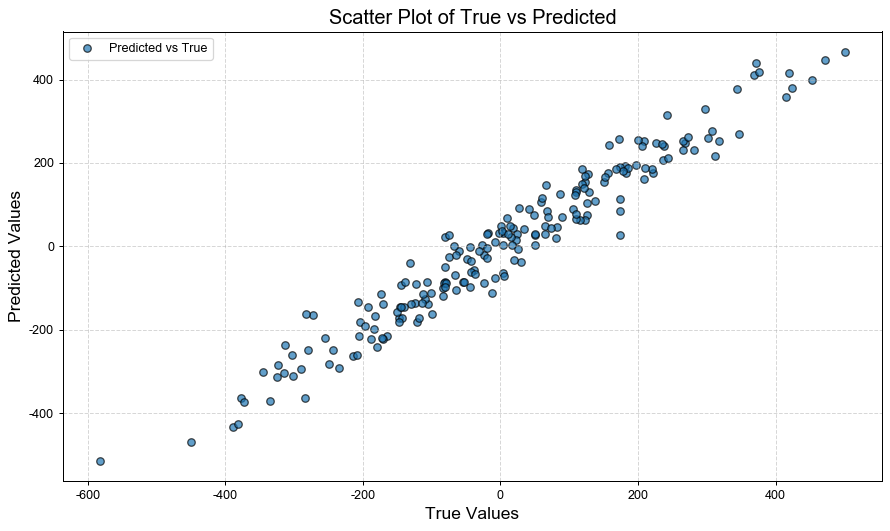

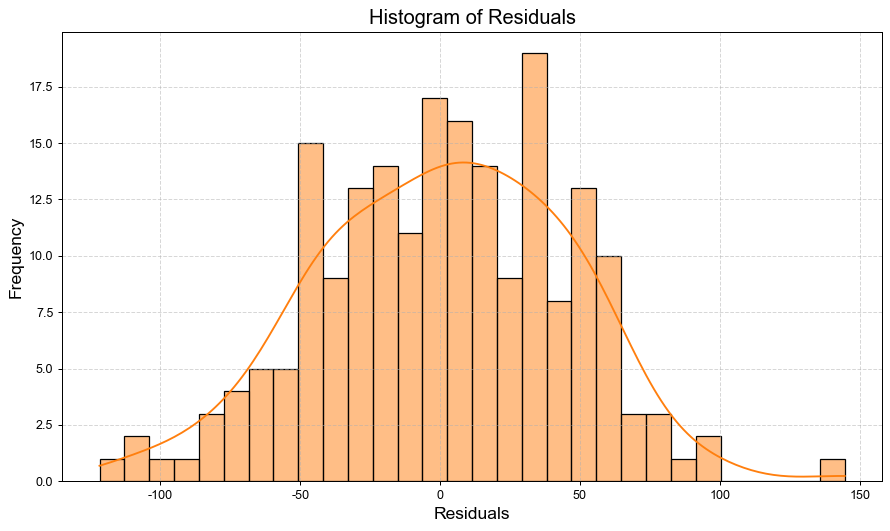

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# 生成回归问题的合成数据集
# n_samples: 样本数, n_features: 特征数, noise: 噪声水平
X, y = make_regression(n_samples=1000, n_features=20, noise=0.1)

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义基础模型
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('svr', SVR(C=1.0, epsilon=0.1))
]

# 定义元学习器，并通过网格搜索进行参数优化
# 这里我们使用 Ridge 回归作为元学习器，通过 GridSearchCV 优化 alpha 参数
ridge = Ridge()
param_grid = {
    'alpha': [0.1, 1.0]
}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', error_score='raise')
# 为元学习器构造Stacking回归器，先用默认的 Ridge，然后后续再替换为调优后的最佳模型
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=ridge,  # 先用未调参的Ridge
    cv=5
)

# 对完整 StackingRegressor 调参；元特征由内部交叉验证产生。
param_grid = {'final_estimator__alpha': [0.1, 1.0]}
grid_search = GridSearchCV(stacking_model, param_grid, cv=3, scoring='neg_mean_squared_error', error_score='raise')
grid_search.fit(X_train, y_train)
optimized_stacking_model = grid_search.best_estimator_
print('最佳元学习器参数:', grid_search.best_params_)

# 对测试集进行预测
y_pred = optimized_stacking_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test Mean Squared Error:", mse)

# 计算残差
residuals = y_test - y_pred


# 可视化：预测值与真实值散点图
plt.figure(figsize=(10, 6))
# 绘制散点图
plt.scatter(y_test, y_pred, color='tab:blue', alpha=0.7, edgecolor='k', label='Predicted vs True')
plt.xlabel('True Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14) 
plt.title('Scatter Plot of True vs Predicted', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 可视化：残差直方图
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='tab:orange', bins=30)
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Residuals', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- **数据生成和划分**：使用 `make_regression` 生成合成回归数据，并划分为训练集和测试集。
- **基础模型**：选取随机森林、梯度提升回归和支持向量机回归，捕捉数据中不同的模式。
- **元学习器调参**：利用 GridSearchCV 优化 Ridge 模型的超参数 `alpha`，提升模型综合能力。
- **堆叠模型构建与训练**：通过 `StackingRegressor` 将基础模型与优化后的元学习器组合，并训练堆叠模型。
- **可视化**：生成散点图和残差直方图，使用配 "tab:blue" 和 "tab:orange"展示模型表现。

![原文参考图，当前结果见代码输出](attachments/img_001.png)

![原文参考图，当前结果见代码输出](attachments/img_002.png)

该案例充分演示了堆叠集成算法的整个流程，并通过可视化和超参数优化增强了模型的实用性和解释性。

## 模型分析

### 堆叠优缺点

**优点：**

1. **利用多个模型的优势**：堆叠集成多个基础模型，结合它们的长处，提高泛化能力。比如，随机森林擅长处理高维数据，梯度提升回归在复杂模式下表现优异，SVM 适用于小样本数据。
2. **减少过拟合**：相比单一模型，Stacking 通过不同模型的组合降低了过拟合风险。不同模型可能对数据的不同方面做出正确判断，从而互相弥补不足。
3. **灵活性强**：可以搭配各种基础学习器，并使用任意复杂的元学习器（如线性回归、XGBoost、深度学习模型），适用于各种任务。
4. **可调优**：使用交叉验证 + 超参数优化（如 GridSearchCV）来优化元学习器，使得最终模型更具鲁棒性。

**缺点：**

1. **计算成本高**：训练多个基础模型 + 训练一个元学习器，计算开销大，训练和预测时间较长。
2. **难以解释**：相较于单个模型（如线性回归），Stacking 的层次化结构较难解释，可解释性较差。
3. **依赖于基础模型表现**：如果基础模型本身表现不好，Stacking 也无法显著提高性能，甚至可能降低模型效果。
4. **信息泄露风险**：如果没有正确使用交叉验证来生成第一层预测值，可能会发生信息泄露，导致过拟合。

### 堆叠与其他集成方法的对比

| 特性 | Stacking（堆叠） | Bagging（如随机森林） | Boosting（如 XGBoost） | Blending |
|-|-|-|-|-|
| **方法核心** | 组合多个不同模型，由元学习器学习如何融合它们的预测 | 通过对样本随机采样，训练多个相同类型的模型，并平均预测 | 依次训练多个模型，让后一个模型专注于修正前一个模型的错误 | 类似 Stacking，但仅用训练集预测值训练元学习器 |
| **基础模型的多样性** | 允许不同类型的基础模型（如决策树、SVM、神经网络等） | 主要使用同类型的模型，如决策树 | 主要使用弱模型（如决策树），逐步提升整体性能 | 可以使用不同模型，但通常仅限于少量 |
| **是否依赖元学习器** | 需要一个额外的元学习器来融合结果 | 无需额外元学习器，直接平均或投票 | 无需额外元学习器，通过加权迭代学习 | 需要，但通常是一个简单的模型 |
| **计算开销** | 高，需要训练多个模型 + 一个元学习器 | 适中，可以并行训练多个模型 | 较高，模型训练是串行的（后一个模型依赖前一个模型） | 较低，只需训练少量基础模型 |
| **是否容易过拟合** | 适当使用交叉验证可降低过拟合风险 | 低，适用于高方差问题 | 高，若学习率设置不当，容易过拟合 | 低，因为它使用一个独立的验证集 |
| **解释性** | 低，难以解释最终预测结果 | 中等，个体树的决策路径可以分析 | 低，难以解释加权迭代过程 | 中等，比 Stacking 稍好 |

### 何时优选 Stacking，何时使用其他算法？

**优选 Stacking 的情况**：

1. **数据较大、计算资源充足**：由于 Stacking 计算量大，适合处理大数据集，并且适用于分布式计算环境。
2. **需要结合多种模型优点**：当单一模型无法很好地拟合数据时，使用多个模型的 Stacking 可能会提供更好的结果。
3. **任务对准确性要求高**：如 Kaggle 竞赛、金融预测等，需要极致的预测精度，而非可解释性。
4. **数据异质性较高**：如果数据的模式复杂，可能需要不同的模型捕捉不同的特征，这时 Stacking 比 Bagging 或 Boosting 更有效。

**优选其他方法的情况**：

1. **计算资源有限（选择 Bagging）**：如果计算能力有限但仍希望降低方差，Bagging（如随机森林）是更好的选择。
2. **需要更快的训练时间（选择 Boosting）**：如果希望快速训练一个强大的模型，可以选择 Boosting（如 XGBoost、LightGBM）。
3. **需要高可解释性（选择线性模型或决策树）**：如果任务对模型的可解释性要求较高（如医疗、生物学领域），Boosting 或 Bagging 比 Stacking 更合适，甚至可以选择简单的线性模型或决策树。
4. **数据量较小（选择 Blending）**：当数据集较小，训练多个模型可能会导致过拟合，此时可以考虑 Blending，它是一个更轻量的 Stacking 变体。

### 总结

Stacking 是一种强大的集成学习方法，适合需要高预测精度且计算资源充足的情况，尤其是在数据复杂的任务中。

计算资源有限时，可以优先选择 Bagging（降低方差）或 Boosting（提高准确性）。需要可解释性时，可以使用决策树或回归模型，而不是 Stacking。

数据较小时，Blending 是一个更轻量的选择，避免 Stacking 可能带来的过拟合问题。